# 02 · Sobreajuste, subajuste y validación cruzada

Objetivo: **ver** el sobreajuste con números, entender por qué se separan los datos en
entrenamiento/validación/prueba y por qué con solo 144 partidos una sola partición
puede mentir.

Ruta:
1. Intuición con datos sintéticos: polinomios de grado 1, 4 y 15.
2. El dataset de Champions limpio (igual que en el tema 01).
3. Un árbol variando `max_depth`: train vs test.
4. `validation_curve` con `StratifiedKFold`.
5. `KFold` vs `StratifiedKFold`: qué pasa con los empates.
6. Una sola partición vs validación cruzada: ¿cuánto varía la métrica?
7. `learning_curve`: ¿faltan datos o falta información?
8. Muestras pequeñas: la varianza de la métrica según el tamaño del test.
9. Regularización (`C` en regresión logística) y *early stopping*.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import (KFold, StratifiedKFold, cross_val_score,
                                     learning_curve, train_test_split, validation_curve)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 100

## 1. Intuición: tres polinomios

Generamos 30 puntos de una curva seno con ruido y ajustamos polinomios de grado 1, 4 y
15. El grado es la **capacidad** del modelo: cuántas "curvas" puede hacer.

- Grado 1 (una recta): demasiado simple → **subajuste** (alto sesgo).
- Grado 15: tan flexible que pasa por cada punto, **incluido el ruido** → **sobreajuste**
  (alta varianza).
- Grado 4: el punto medio.

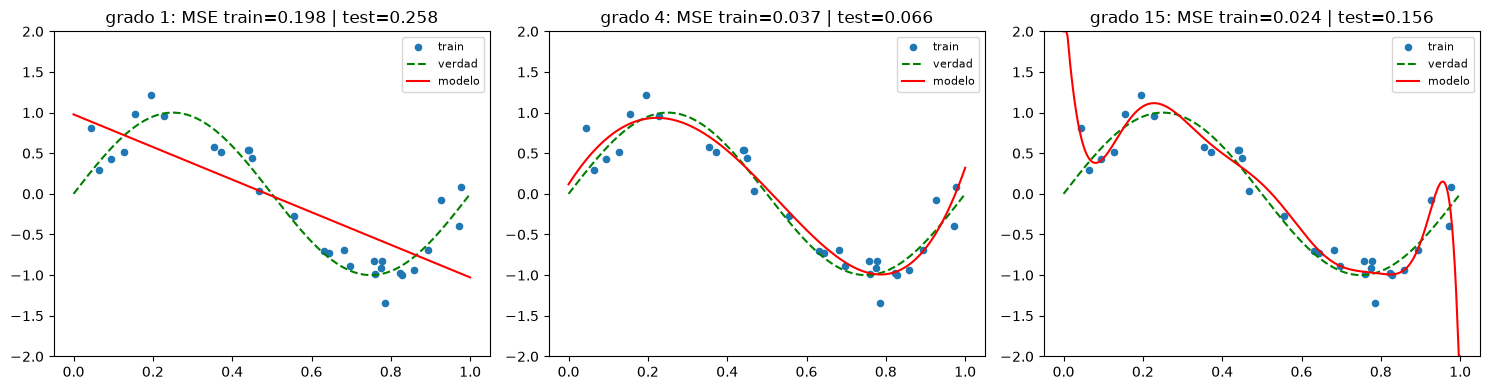

,grado,MSE_train,MSE_test
0,1,0.198,0.258
1,4,0.037,0.066
2,15,0.024,0.156


In [2]:
x_train = np.sort(rng.uniform(0, 1, 30))
y_train = np.sin(2 * np.pi * x_train) + rng.normal(0, 0.25, 30)
x_test = np.sort(rng.uniform(0, 1, 200))
y_test = np.sin(2 * np.pi * x_test) + rng.normal(0, 0.25, 200)
x_plot = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
filas = []
for ax, grado in zip(axes, [1, 4, 15]):
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo.fit(x_train[:, None], y_train)
    mse_tr = mean_squared_error(y_train, modelo.predict(x_train[:, None]))
    mse_te = mean_squared_error(y_test, modelo.predict(x_test[:, None]))
    filas.append({"grado": grado, "MSE_train": round(mse_tr, 3), "MSE_test": round(mse_te, 3)})
    ax.scatter(x_train, y_train, s=20, label="train")
    ax.plot(x_plot, np.sin(2 * np.pi * x_plot), "g--", label="verdad")
    ax.plot(x_plot, np.clip(modelo.predict(x_plot[:, None]), -2, 2), "r", label="modelo")
    ax.set_title(f"grado {grado}: MSE train={mse_tr:.3f} | test={mse_te:.3f}")
    ax.set_ylim(-2, 2); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
pd.DataFrame(filas)

**Interpretación:** el error de **entrenamiento siempre baja** al subir el grado (el
modelo de grado 15 tiene el menor MSE_train), pero el error de **prueba** dibuja una U:
alto con grado 1 (no captura la curva), mínimo cerca de grado 4 y se dispara con grado
15 (memorizó el ruido). Moraleja: **el error de entrenamiento no sirve para elegir
modelos**; necesitamos datos que el modelo no vio.

## 2. El dataset de Champions, limpio como en el tema 01

Quitamos las 7 filas vacías, descartamos `score`/`winner` (fuga) y convertimos el texto
a números. Usamos solo las 14 variables numéricas (sin el One-Hot de equipos) para que
los modelos sean rápidos y el efecto sea fácil de ver.

In [3]:
df = pd.read_csv("../datos/champions_league_matches.csv").dropna(how="all").reset_index(drop=True)

X = pd.DataFrame({
    "home_possession": df["home_possession"].str.rstrip("%").astype(float),
    "away_possession": df["away_possession"].str.rstrip("%").astype(float),
})
for col in ["home_shots_on_target", "away_shots_on_target", "home_saves", "away_saves"]:
    partes = df[col].str.extract(r"(\d+)\s*of\s*(\d+)").astype(float)
    X[f"{col}_hechos"], X[f"{col}_intentos"] = partes[0], partes[1]
for col in ["home_shots_on_target_pct", "away_shots_on_target_pct", "home_saves_pct", "away_saves_pct"]:
    X[col] = df[col]
X = X.fillna(X.median())          # 3 nulos de home_saves_pct ('0 of 0')
y = df["result"]
print("X:", X.shape, "| clases:", y.value_counts().to_dict())

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("train:", X_tr.shape[0], "| test:", X_te.shape[0])

X: (144, 14) | clases: {'Home Win': 71, 'Away Win': 48, 'Draw': 25}
train: 115 | test: 29


Es la misma partición que usó el curso: **115 de entrenamiento y 29 de prueba**,
estratificada con semilla 42.

## 3. Árbol de decisión: `max_depth` de 1 a 15

`max_depth` es la perilla de capacidad del árbol: cuántas preguntas seguidas puede hacer.
Un árbol sin límite puede seguir partiendo hasta que cada hoja tenga un solo partido.

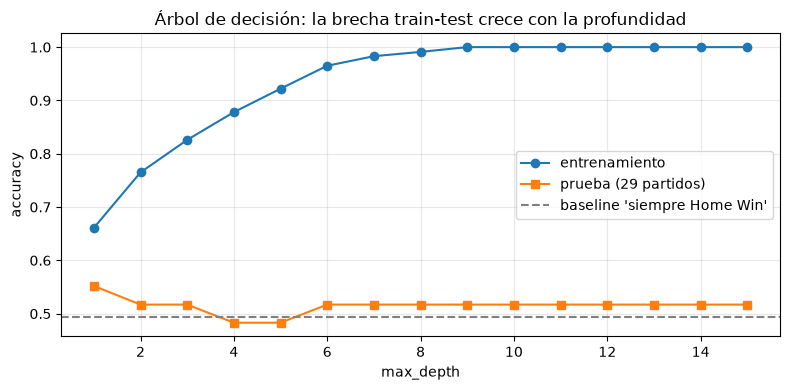

,max_depth,acc_train,acc_test,hojas
0,1,0.661,0.552,2
1,2,0.765,0.517,4
2,3,0.826,0.517,8
3,4,0.878,0.483,13
4,5,0.922,0.483,20
5,6,0.965,0.517,26
6,7,0.983,0.517,28
7,8,0.991,0.517,30
8,9,1.000,0.517,31
9,10,1.000,0.517,31


In [4]:
filas = []
for d in range(1, 16):
    arbol = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_tr, y_tr)
    filas.append({"max_depth": d,
                  "acc_train": accuracy_score(y_tr, arbol.predict(X_tr)),
                  "acc_test": accuracy_score(y_te, arbol.predict(X_te)),
                  "hojas": arbol.get_n_leaves()})
prof = pd.DataFrame(filas).round(3)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(prof.max_depth, prof.acc_train, "o-", label="entrenamiento")
ax.plot(prof.max_depth, prof.acc_test, "s-", label="prueba (29 partidos)")
ax.axhline(71 / 144, ls="--", c="gray", label="baseline 'siempre Home Win'")
ax.set_xlabel("max_depth"); ax.set_ylabel("accuracy"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Árbol de decisión: la brecha train-test crece con la profundidad")
plt.tight_layout()
plt.show()
prof

**Interpretación:** el accuracy de entrenamiento sube de 0.661 (`max_depth=1`) a
**1.000** desde `max_depth=9` (31 hojas: memorizó los 115 partidos), mientras que el de
prueba **nunca mejora**: empieza en 0.552 y se queda entre 0.483 y 0.517, pegado al
baseline de 0.483 (14 de 29). Un árbol solo, con tan pocos datos, no generaliza. La **brecha** entre ambas curvas es el sobreajuste. Fíjate además en lo
*saltón* que es la curva de prueba: con 29 partidos, cada acierto vale 3.4 puntos. Elegir
`max_depth` mirando esta curva sería hacer trampa (y además con mucho ruido): para eso
está la validación cruzada.

## 4. `validation_curve`: lo mismo, pero honesto

`validation_curve` hace validación cruzada para cada valor del hiperparámetro **solo con
los datos de entrenamiento**. El test queda guardado. Usamos `StratifiedKFold(5)` y
`f1_macro` (la métrica del curso, que pesa igual a los empates).

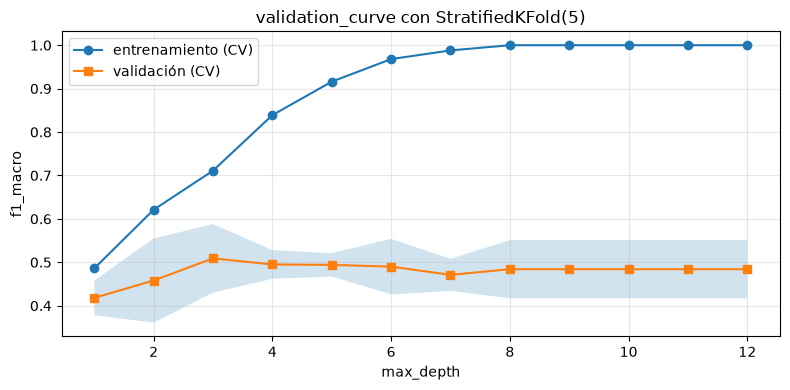

max_depth con mejor f1_macro en validación: 3


,max_depth,train_media,val_media,val_std
0,1,0.486,0.418,0.040
1,2,0.621,0.458,0.097
2,3,0.711,0.509,0.079
3,4,0.839,0.495,0.033
4,5,0.916,0.494,0.027
5,6,0.968,0.490,0.064
6,7,0.988,0.471,0.037
7,8,1.000,0.484,0.067
8,9,1.000,0.484,0.067
9,10,1.000,0.484,0.067


In [5]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
profundidades = np.arange(1, 13)
tr_sc, va_sc = validation_curve(DecisionTreeClassifier(random_state=RANDOM_STATE), X_tr, y_tr,
                                param_name="max_depth", param_range=profundidades,
                                cv=cv5, scoring="f1_macro")
vc = pd.DataFrame({"max_depth": profundidades,
                   "train_media": tr_sc.mean(1), "val_media": va_sc.mean(1), "val_std": va_sc.std(1)}).round(3)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(vc.max_depth, vc.train_media, "o-", label="entrenamiento (CV)")
ax.plot(vc.max_depth, vc.val_media, "s-", label="validación (CV)")
ax.fill_between(vc.max_depth, vc.val_media - vc.val_std, vc.val_media + vc.val_std, alpha=0.2)
ax.set_xlabel("max_depth"); ax.set_ylabel("f1_macro"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("validation_curve con StratifiedKFold(5)")
plt.tight_layout()
plt.show()
mejor_d = int(vc.loc[vc.val_media.idxmax(), "max_depth"])
print("max_depth con mejor f1_macro en validación:", mejor_d)
vc

**Interpretación:** la curva de entrenamiento sube de 0.486 a 1.000 y la de validación
se queda plana entre 0.42 y 0.51 (máximo 0.509 en `max_depth=3`), con desviaciones
estándar de hasta 0.097 entre folds. Esto es
lo mismo que se vio en la Actividad 3 con el bosque aleatorio ("la curva de
entrenamiento se dispara hacia 1.0 mientras la de validación se queda plana"). La
profundidad que elegiríamos es la del máximo de validación, pero la banda dice que varias
profundidades son estadísticamente equivalentes: con tan pocos datos, preferimos la más
**simple** de ellas.

## 5. `KFold` vs `StratifiedKFold`

`KFold` corta los datos en bloques **sin mirar la clase**. `StratifiedKFold` reparte cada
clase proporcionalmente en cada fold. Con 25 empates en 144 partidos, ¿cuántos empates le
tocan a cada fold de validación?

In [6]:
def empates_por_fold(cv):
    return [int((y.iloc[val] == "Draw").sum()) for _, val in cv.split(X, y)]

print("Empates por fold de validación (esperado ≈ 25/5 = 5):")
print("  KFold sin barajar        :", empates_por_fold(KFold(5)))
print("  KFold barajado           :", empates_por_fold(KFold(5, shuffle=True, random_state=RANDOM_STATE)))
print("  StratifiedKFold barajado :", empates_por_fold(StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)))

Empates por fold de validación (esperado ≈ 25/5 = 5):
  KFold sin barajar        : [5, 7, 6, 4, 3]
  KFold barajado           : [5, 4, 5, 6, 5]
  StratifiedKFold barajado : [5, 5, 5, 5, 5]


**Interpretación:** con `KFold` sin barajar los folds reciben entre 3 y 7 empates; así
que el `f1` de la clase `Draw` en cada fold se calcula sobre conjuntos de tamaño muy
distinto. `StratifiedKFold` deja 5 empates (±1) en cada fold. Por eso todo el curso usa
`stratify=y` en el `train_test_split` y `StratifiedKFold` en la calibración.

Ojo con `KFold` sin barajar: el CSV está ordenado por fecha, así que cada fold sería un
bloque de jornadas. Eso no es malo en sí (de hecho, en series de tiempo es lo correcto,
ver tema 03), pero hay que saber que lo estás haciendo.

## 6. ¿Cuánto puede mentir una sola partición?

Repetimos `train_test_split` con 100 semillas distintas y medimos el accuracy de prueba
de un modelo fijo (regresión logística regularizada, la familia que ganó en la
Actividad 3). Luego lo comparamos con validación cruzada 5-fold repetida.

Una sola partición (100 semillas): media=0.765  std=0.049  min=0.655  max=0.897
CV 5-fold (20 repeticiones)      : media=0.768  std=0.015  min=0.743  max=0.792


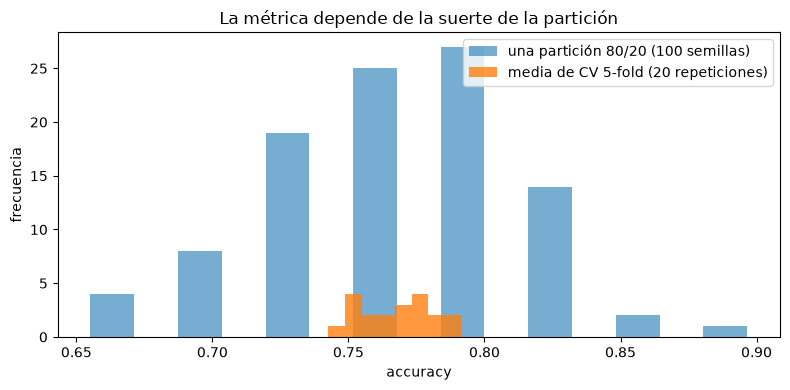

In [7]:
modelo_lr = make_pipeline(StandardScaler(), LogisticRegression(C=0.5, max_iter=5000))

accs_split = []
for semilla in range(100):
    a_tr, a_te, b_tr, b_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=semilla)
    accs_split.append(accuracy_score(b_te, modelo_lr.fit(a_tr, b_tr).predict(a_te)))
accs_split = np.array(accs_split)

accs_cv = np.array([cross_val_score(modelo_lr, X, y, scoring="accuracy",
                                    cv=StratifiedKFold(5, shuffle=True, random_state=s)).mean()
                    for s in range(20)])

print(f"Una sola partición (100 semillas): media={accs_split.mean():.3f}  "
      f"std={accs_split.std():.3f}  min={accs_split.min():.3f}  max={accs_split.max():.3f}")
print(f"CV 5-fold (20 repeticiones)      : media={accs_cv.mean():.3f}  "
      f"std={accs_cv.std():.3f}  min={accs_cv.min():.3f}  max={accs_cv.max():.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(accs_split, bins=15, alpha=0.6, label="una partición 80/20 (100 semillas)")
ax.hist(accs_cv, bins=8, alpha=0.8, label="media de CV 5-fold (20 repeticiones)")
ax.set_xlabel("accuracy"); ax.set_ylabel("frecuencia"); ax.legend()
ax.set_title("La métrica depende de la suerte de la partición")
plt.tight_layout()
plt.show()

**Interpretación:** con una sola partición, el mismo modelo "sale" con accuracy desde
**0.655 hasta 0.897** según la semilla: 24 puntos de diferencia sin cambiar nada del
modelo (desviación estándar 0.049). La media de CV 5-fold varía solo entre 0.743 y 0.792
(desviación 0.015, tres veces menos). Si reportas el que te tocó,
podrías estar reportando suerte. La media de una validación cruzada usa los 144 partidos
como validación una vez cada uno y su variación entre repeticiones es mucho menor.
Por eso: **se elige con CV** y el test reservado se usa una sola vez, al final, como
confirmación.

## 7. `learning_curve`: ¿más datos ayudarían?

`learning_curve` entrena con porciones crecientes del entrenamiento y mide train y
validación. Diagnóstico clásico:
- Las dos curvas **lejos** y la de validación todavía subiendo → más datos ayudarían
  (varianza).
- Las dos curvas **juntas y bajas** → el modelo es muy simple o las variables no traen
  suficiente información (sesgo).

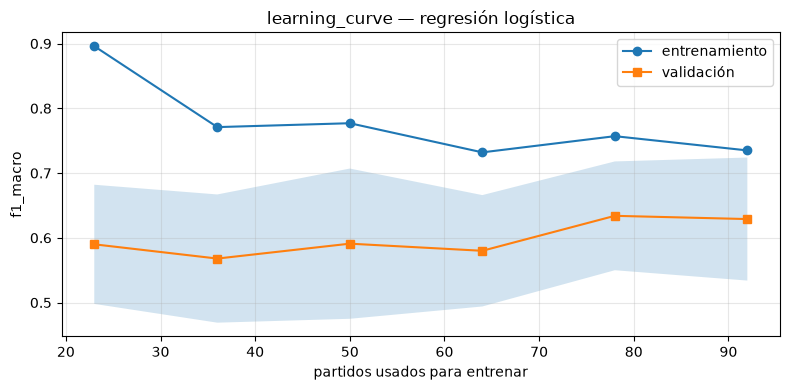

,partidos,train,validacion,val_std
0,23,0.896,0.590,0.092
1,36,0.771,0.568,0.099
2,50,0.777,0.591,0.116
3,64,0.732,0.580,0.086
4,78,0.757,0.634,0.084
5,92,0.735,0.629,0.095


In [8]:
tamanos, lc_tr, lc_va = learning_curve(modelo_lr, X_tr, y_tr, cv=cv5, scoring="f1_macro",
                                       train_sizes=np.linspace(0.25, 1.0, 6))
lc = pd.DataFrame({"partidos": tamanos, "train": lc_tr.mean(1), "validacion": lc_va.mean(1),
                   "val_std": lc_va.std(1)}).round(3)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lc.partidos, lc.train, "o-", label="entrenamiento")
ax.plot(lc.partidos, lc.validacion, "s-", label="validación")
ax.fill_between(lc.partidos, lc.validacion - lc.val_std, lc.validacion + lc.val_std, alpha=0.2)
ax.set_xlabel("partidos usados para entrenar"); ax.set_ylabel("f1_macro")
ax.set_title("learning_curve — regresión logística"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
lc

**Interpretación:** la validación pasa de 0.590 con 23 partidos a 0.629-0.634 con 78-92,
con una banda de ±0.09; el entrenamiento baja de 0.896 a 0.735 acercándose a ella. Es el mismo patrón que
documentó la Actividad 3 (subía hasta ~66 partidos y luego se aplanaba): más partidos
**del mismo tipo** ya no ayudan mucho; lo que limita es la información de las variables
(para predecir de verdad faltan variables nuevas, como el historial de cada equipo).

## 8. Muestras pequeñas: ¿cuánto vale un acierto?

Con 29 partidos de prueba, cada acierto mueve el accuracy en 1/29 = 3.4 puntos. La
teoría (distribución binomial) dice que la desviación estándar del accuracy medido es

$$\sigma \approx \sqrt{\frac{p(1-p)}{n_{test}}}$$

Lo comprobamos con datos sintéticos: el mismo problema con distintos tamaños de muestra.

In [9]:
X_big, y_big = make_classification(n_samples=20000, n_features=10, n_informative=5,
                                   n_classes=3, n_clusters_per_class=1, class_sep=0.8,
                                   random_state=RANDOM_STATE)
filas = []
for n in [144, 500, 2000, 10000]:
    accs = []
    for s in range(40):
        idx = np.random.default_rng(s).choice(len(y_big), n, replace=False)
        a_tr, a_te, b_tr, b_te = train_test_split(X_big[idx], y_big[idx], test_size=0.2,
                                                  stratify=y_big[idx], random_state=s)
        accs.append(accuracy_score(b_te, LogisticRegression(max_iter=2000).fit(a_tr, b_tr).predict(a_te)))
    p, n_test = np.mean(accs), int(round(n * 0.2))
    filas.append({"n_total": n, "n_test": n_test, "acc_media": round(p, 3),
                  "std_observada": round(np.std(accs), 3),
                  "std_teorica": round(np.sqrt(p * (1 - p) / n_test), 3),
                  "valor_de_1_acierto": round(1 / n_test, 4)})
muestras = pd.DataFrame(filas)
muestras

,n_total,n_test,acc_media,std_observada,std_teorica,valor_de_1_acierto
0,144,29,0.765,0.089,0.079,0.0345
1,500,100,0.802,0.044,0.040,0.0100
2,2000,400,0.811,0.018,0.020,0.0025
3,10000,2000,0.815,0.008,0.009,0.0005


**Interpretación:** con 144 filas (29 de test) la desviación estándar observada del
accuracy es **0.089** (la fórmula da 0.079): casi 9 puntos de ruido puro. Con 10 000 filas
baja a 0.008, menos de un punto. La regla: **el error de medición se reduce con la raíz de n** (para
reducirlo a la mitad necesitas 4 veces más datos de prueba). Cuando la Actividad 3 dice
que "cada acierto vale 3.4 puntos de accuracy", está diciendo exactamente esto.

## 9. Remedios: regularización y *early stopping*

### 9.1 Regularización en la regresión logística (`C`)
La regresión logística penaliza coeficientes grandes. En scikit-learn `C` es el
**inverso** de la fuerza de regularización: `C` chico = mucha regularización (modelo
simple, coeficientes cerca de cero), `C` grande = casi sin freno (modelo flexible).

Comparamos dos versiones del dataset, como en el curso:
- **14 numéricas** (las de arriba).
- **14 numéricas + 72 columnas One-Hot de equipos** = 86 columnas, exactamente lo que
  producía el preprocesamiento de las Actividades 1 y 3.

Usamos `RepeatedStratifiedKFold` (5 folds × 4 repeticiones) para suavizar el ruido.

Columnas con equipos: 86


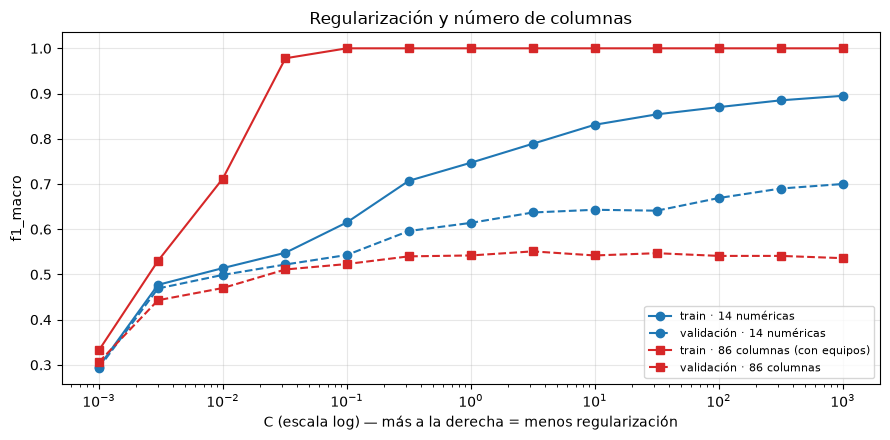

,C,train_14num,val_14num,train_86col,val_86col
0,0.001,0.296,0.293,0.332,0.306
1,0.003,0.477,0.469,0.530,0.443
2,0.010,0.514,0.499,0.712,0.470
3,0.032,0.548,0.522,0.978,0.511
4,0.100,0.615,0.543,1.000,0.523
5,0.316,0.707,0.596,1.000,0.540
6,1.000,0.747,0.614,1.000,0.542
7,3.162,0.789,0.637,1.000,0.551
8,10.000,0.831,0.643,1.000,0.542
9,31.623,0.854,0.641,1.000,0.547


In [10]:
from sklearn.model_selection import RepeatedStratifiedKFold

equipos = pd.get_dummies(df[["home_team", "away_team"]]).astype(float)
X86 = pd.concat([X, equipos], axis=1)
X86_tr = X86.loc[X_tr.index]          # misma partición de entrenamiento que antes
print("Columnas con equipos:", X86.shape[1])

cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=RANDOM_STATE)
Cs = np.logspace(-3, 3, 13)
reg = {"C": Cs}
for nombre, datos in [("14num", X_tr), ("86col", X86_tr)]:
    tr_c, va_c = validation_curve(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
                                  datos, y_tr, param_name="logisticregression__C", param_range=Cs,
                                  cv=cv_rep, scoring="f1_macro")
    reg[f"train_{nombre}"], reg[f"val_{nombre}"] = tr_c.mean(1), va_c.mean(1)
reg = pd.DataFrame(reg).round(3)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogx(reg.C, reg.train_14num, "o-", c="tab:blue", label="train · 14 numéricas")
ax.semilogx(reg.C, reg.val_14num, "o--", c="tab:blue", label="validación · 14 numéricas")
ax.semilogx(reg.C, reg.train_86col, "s-", c="tab:red", label="train · 86 columnas (con equipos)")
ax.semilogx(reg.C, reg.val_86col, "s--", c="tab:red", label="validación · 86 columnas")
ax.set_xlabel("C (escala log) — más a la derecha = menos regularización")
ax.set_ylabel("f1_macro"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title("Regularización y número de columnas")
plt.tight_layout()
plt.show()
reg

**Interpretación (con los números de la tabla):**
- **Con 86 columnas** el train llega a **1.000** desde `C = 0.1`: con 86 columnas y ~92
  partidos por fold, el modelo puede separar perfectamente el entrenamiento usando "quién
  jugó". La validación no pasa de ~0.55. Esa brecha de casi medio punto es sobreajuste de
  libro, causado por **demasiadas columnas para tan pocas filas**. Regularizar fuerte
  (`C` chico) cierra la brecha, pero bajando también la validación: el remedio de fondo
  fue quitar ruido (`SelectKBest` en la Actividad 3).
- **Con 14 numéricas** la validación es más alta en casi todo el rango y sigue subiendo
  cuando quitamos regularización (llega a ~0.70 con `C = 1000`). ¿Por qué aquí "menos
  freno" ayuda? Porque una combinación lineal de estas columnas (tiros a puerta −
  atajadas rivales ≈ goles) reconstruye el marcador: es la **fuga indirecta** del tema 01
  y el modelo flexible la explota. No es una regla general; es una pista de que algo en los
  datos es "demasiado bueno".
- Lección práctica: la regularización es una perilla más y su mejor valor depende de los
  datos. Por eso se calibra con CV (Actividad 3: `C ≈ 0.54` junto con `SelectKBest(k=40)`).

### 9.2 *Early stopping* en gradient boosting
El boosting agrega árboles uno tras otro; cada árbol nuevo corrige errores del anterior.
Si agregas demasiados, empieza a corregir **ruido**. *Early stopping* separa un pedazo
de validación interno y detiene el entrenamiento cuando la validación deja de mejorar.
Lo vemos con datos sintéticos (más filas para que la curva sea clara).

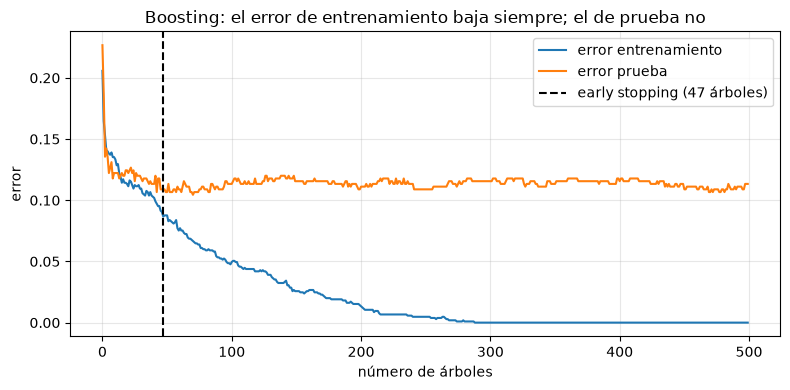

Sin early stopping (500 árboles): acc test = 0.887
Con early stopping (47 árboles): acc test = 0.893
Mejor número de árboles visto en prueba: 71


In [11]:
Xs, ys = make_classification(n_samples=1500, n_features=20, n_informative=5, flip_y=0.1,
                             random_state=RANDOM_STATE)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.3, random_state=RANDOM_STATE)

gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.1, max_depth=3,
                                random_state=RANDOM_STATE).fit(Xs_tr, ys_tr)
err_tr = [1 - accuracy_score(ys_tr, p) for p in gb.staged_predict(Xs_tr)]
err_te = [1 - accuracy_score(ys_te, p) for p in gb.staged_predict(Xs_te)]

gb_es = GradientBoostingClassifier(n_estimators=500, learning_rate=0.1, max_depth=3,
                                   validation_fraction=0.2, n_iter_no_change=10,
                                   random_state=RANDOM_STATE).fit(Xs_tr, ys_tr)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(err_tr, label="error entrenamiento")
ax.plot(err_te, label="error prueba")
ax.axvline(gb_es.n_estimators_, c="k", ls="--", label=f"early stopping ({gb_es.n_estimators_} árboles)")
ax.set_xlabel("número de árboles"); ax.set_ylabel("error"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Boosting: el error de entrenamiento baja siempre; el de prueba no")
plt.tight_layout()
plt.show()

print(f"Sin early stopping (500 árboles): acc test = {accuracy_score(ys_te, gb.predict(Xs_te)):.3f}")
print(f"Con early stopping ({gb_es.n_estimators_} árboles): acc test = {accuracy_score(ys_te, gb_es.predict(Xs_te)):.3f}")
print(f"Mejor número de árboles visto en prueba: {int(np.argmin(err_te)) + 1}")

**Interpretación:** el error de entrenamiento baja casi hasta cero con 500 árboles,
pero el de prueba toca fondo alrededor del árbol 71 y después se estanca. *Early
stopping* se detuvo en **47 árboles** (menos de una décima parte), entrenó más rápido y
obtuvo 0.893 de accuracy en prueba contra 0.887 con los 500, **sin haber mirado el test** (usó su propio 20 % de validación).

## Resumen

| Síntoma | Diagnóstico | Remedios |
|---|---|---|
| Train bajo y validación baja (juntas) | **Subajuste** (alto sesgo) | más capacidad, mejores variables, menos regularización |
| Train altísimo y validación baja (brecha) | **Sobreajuste** (alta varianza) | limitar `max_depth`/`min_samples_leaf`, regularizar (`C` menor), early stopping, menos variables (`SelectKBest`), más datos |
| Validación plana al crecer los datos | límite de información | variables nuevas, no más filas |

- El error de entrenamiento **no** sirve para elegir modelos.
- Train / validación / test: se **aprende** con train, se **elige** con validación
  (idealmente CV) y se **confirma una sola vez** con test.
- Con clases desbalanceadas, `StratifiedKFold` y `stratify=y`.
- Con muestras pequeñas la métrica tiene un error de medición grande (σ ≈ √(p(1−p)/n)):
  reporta media ± desviación, no un solo número.
- En MLOps esto importa porque un modelo sobreajustado **se ve espectacular en el
  notebook y falla en producción**; la compuerta de calidad del pipeline (tema 10) y el
  monitoreo (tema 00) existen para no dejarse engañar.